# Prognoza zamówień e-commerce 

End-to-end pipeline forecastingowy na danych **Databricks Marketplace "Simulated Retail Customer Data"**.

**Tabele:** `databricks_simulated_retail_customer_data.v01.sales_orders`, `.sales`, `.customers`

| Parametr | Wartość |
| --- | --- |
| **Cel (target)** | `n_orders` — dzienna liczba unikalnych zamówień |
| **Granulacja** | 1 dzień — agregujemy wszystkie zamówienia z danego dnia do jednej wartości |
| **Holdout** | Ostatnie 14 dni — model trenujemy na wcześniejszych danych, a na końcowych 14 dniach mierzymy dokładność |

## 1. Data Explorer

W tej sekcji ładujemy dane źródłowe, konwertujemy czas zamówienia do daty, parsujemy JSON z listą produktów i budujemy podstawowy widok dzienny. Dzięki temu widać skalę danych, zakres dat oraz bazowe trendy zamówień i przychodu.

=== DATA EXPLORER ===
sales_orders : 4,074 rows
sales        : 360 rows
customers    : 28,813 rows
Deduplicated sales_orders: removed 74 duplicate order_number rows
Date range : 2019-08-01 to 2019-11-14 (106 days)
Exploded line items: 7,948


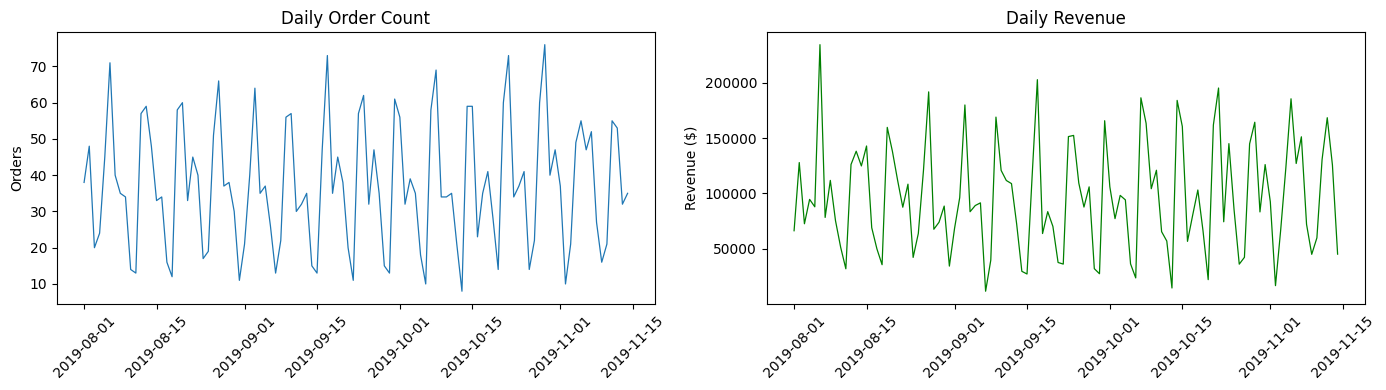


--- Top Product Categories (sales table) ---


product_category,n_rows,total_price
Rony,118,947658
Sioneer,89,640831
Opple,67,581853
Ramsung,68,474119
Zamaha,13,70534
Reagate,5,21031


In [0]:
# 1. DATA EXPLORER

import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType, StructType, StructField, StringType
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

CAT = "databricks_simulated_retail_customer_data"

# ---- Load tables ----
orders_raw = spark.table(f"{CAT}.v01.sales_orders")
sales_raw = spark.table(f"{CAT}.v01.sales")
customers = spark.table(f"{CAT}.v01.customers")

print("=== DATA EXPLORER ===")
print(f"sales_orders : {orders_raw.count():,} rows")
print(f"sales        : {sales_raw.count():,} rows")
print(f"customers    : {customers.count():,} rows")

# ---- Convert epoch to date ----
orders = orders_raw.withColumn("order_date", F.to_date(F.from_unixtime("order_datetime")))

# ---- Deduplicate order_number ----
# Exact duplicate rows are dropped outright; any rows that still share an
# order_number after that (e.g. re-ingested with different values) are resolved
# deterministically by keeping one row per order_number, so revenue/item
# aggregates below don't double count. The raw finding is reported by the Data
# Validator (section 2), which checks orders_raw independently of this fix.
n_before = orders.count()
orders = orders.dropDuplicates()
dedupe_window = Window.partitionBy("order_number").orderBy(F.monotonically_increasing_id())
orders = (
    orders
    .withColumn("_row_rank", F.row_number().over(dedupe_window))
    .filter(F.col("_row_rank") == 1)
    .drop("_row_rank")
)
n_after = orders.count()
print(f"Deduplicated sales_orders: removed {n_before - n_after:,} duplicate order_number rows")

date_stats = orders.agg(
    F.min("order_date").alias("min_date"),
    F.max("order_date").alias("max_date"),
    F.countDistinct("order_date").alias("n_days"),
).collect()[0]
print(f"Date range : {date_stats['min_date']} to {date_stats['max_date']} ({date_stats['n_days']} days)")

# ---- Parse ordered_products JSON for item-level revenue only ----
item_schema = ArrayType(StructType([
    StructField("curr", StringType()),
    StructField("id", StringType()),
    StructField("name", StringType()),
    StructField("price", StringType()),
    StructField("promotion_info", StringType()),
    StructField("qty", StringType()),
    StructField("unit", StringType()),
]))

orders_parsed = (
    orders
    .withColumn("items", F.from_json("ordered_products", item_schema))
    .withColumn("item", F.explode("items"))
    .withColumn("item_price", F.col("item.price").cast("double"))
    .withColumn("item_qty", F.col("item.qty").cast("int"))
    .withColumn("line_revenue", F.col("item_price") * F.col("item_qty"))
)

print(f"Exploded line items: {orders_parsed.count():,}")

# ---- Daily aggregation ----
# Count orders before explode so an empty or malformed basket does not remove its order.
daily_orders = (
    orders
    .filter(F.col("order_date").isNotNull())
    .groupBy("order_date")
    .agg(F.countDistinct("order_number").alias("n_orders"))
)
daily_items = (
    orders_parsed
    .groupBy("order_date")
    .agg(
        F.count("*").alias("n_items"),
        F.sum("line_revenue").alias("total_revenue"),
    )
)
calendar = (
    spark.createDataFrame([(date_stats["min_date"], date_stats["max_date"])], ["min_date", "max_date"])
    .select(F.explode(F.sequence("min_date", "max_date")).alias("order_date"))
)
daily_agg = (
    calendar
    .join(daily_orders, "order_date", "left")
    .join(daily_items, "order_date", "left")
    .fillna({"n_orders": 0, "n_items": 0, "total_revenue": 0.0})
    .orderBy("order_date")
)

daily_pd = daily_agg.toPandas()

# ---- Charts ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(daily_pd["order_date"], daily_pd["n_orders"], linewidth=0.9)
axes[0].set_title("Daily Order Count")
axes[0].set_ylabel("Orders")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(daily_pd["order_date"], daily_pd["total_revenue"], linewidth=0.9, color="green")
axes[1].set_title("Daily Revenue")
axes[1].set_ylabel("Revenue ($)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# ---- Top categories from sales table ----
print("\n--- Top Product Categories (sales table) ---")
cat_counts = sales_raw.groupBy("product_category").agg(
    F.count("*").alias("n_rows"),
    F.sum("total_price").alias("total_price"),
).orderBy(F.desc("total_price")).toPandas()
display(cat_counts)

## 2. Data Validator

Tutaj sprawdzamy jakość danych wejściowych dla forecastu: braki, duplikaty, luki w szeregu czasowym, puste koszyki oraz nietypowe wartości przychodu. Duplikaty `order_number` i luki w datach są liczone na surowych danych (`orders_raw`), niezależnie od deduplikacji zastosowanej w sekcji 1 — dzięki temu raport zawsze pokazuje prawdziwy stan źródła, a status `RESOLVED` potwierdza, że naprawa faktycznie zadziałała.

In [0]:
# 2. DATA VALIDATOR

import pyspark.sql.functions as F
import numpy as np
import pandas as pd

report = []

# ---- A. Nulls in key columns ----
for tbl_name, tbl_df, key_cols in [
    ("sales_orders", orders, ["order_number", "customer_id", "order_date", "ordered_products"]),
    ("sales", sales_raw, ["customer_id", "order_date", "total_price"]),
    ("customers", customers, ["customer_id", "state", "loyalty_segment"]),
]:
    for col in key_cols:
        null_cnt = tbl_df.filter(F.col(col).isNull()).count()
        if null_cnt > 0:
            report.append(("WARNING", f"Nulls in {tbl_name}.{col}", f"{null_cnt:,} rows"))

if not any(r[0] != "PASS" for r in report):
    report.append(("PASS", "Null check", "No nulls in key columns"))

# ---- B. Duplicate order_numbers ----
# `orders` was already deduplicated in Data Explorer (section 1); check the
# untouched source table so this always reflects the true raw data quality,
# and confirm the fix actually resolved it.
dupes_raw = orders_raw.groupBy("order_number").count().filter(F.col("count") > 1).count()
dupes_remaining = orders.groupBy("order_number").count().filter(F.col("count") > 1).count()
if dupes_raw == 0:
    report.append(("PASS", "Duplicate order_number", "0 duplicates"))
elif dupes_remaining == 0:
    report.append(("RESOLVED", "Duplicate order_number",
                   f"{dupes_raw:,} found in source, deduplicated in Data Explorer"))
else:
    report.append(("BLOCKER", "Duplicate order_number",
                   f"{dupes_remaining:,} of {dupes_raw:,} duplicates still unresolved"))

# ---- C. Date gaps ----
# Check the raw order dates, not daily_pd: Data Explorer fills missing calendar
# days with zero orders by construction, which would otherwise make this check
# always pass regardless of real gaps in the source data.
raw_dates_pd = (
    orders.filter(F.col("order_date").isNotNull())
    .select("order_date").distinct().toPandas()["order_date"]
)
all_dates = pd.to_datetime(raw_dates_pd, errors="coerce").dropna().dt.date.sort_values()
expected = set(pd.date_range(all_dates.min(), all_dates.max(), freq="D").date)
actual = set(all_dates.tolist())
missing = expected - actual
report.append(("WARNING" if missing else "PASS",
               "Date gaps in daily series", f"{len(missing)} missing days (raw order dates)"))

# ---- D. Empty ordered_products ----
empty_prods = orders.filter(
    F.col("ordered_products").isNull() |
    (F.col("ordered_products") == "") |
    (F.col("ordered_products") == "[]")
).count()
report.append(("WARNING" if empty_prods > 0 else "PASS",
               "Empty ordered_products", f"{empty_prods:,} orders"))

# ---- E. Revenue outliers (MAD) ----
rev = daily_pd["total_revenue"].values
median_rev = np.median(rev)
mad = np.median(np.abs(rev - median_rev))
if mad > 0:
    outlier_days = int(np.sum(np.abs(rev - median_rev) / mad > 3))
else:
    outlier_days = 0
report.append(("WARNING" if outlier_days > 3 else "PASS",
               "Revenue outlier days (MAD>3)", f"{outlier_days} days"))

# ---- Print report ----
print("=== DATA VALIDATOR REPORT ===")
print(f"{'Severity':<10} {'Check':<30} {'Finding'}")
print("-" * 70)
for sev, check, finding in report:
    print(f"{sev:<10} {check:<30} {finding}")

=== DATA VALIDATOR REPORT ===
Severity   Check                          Finding
----------------------------------------------------------------------
WARNING    Nulls in sales_orders.order_date 45 rows
RESOLVED   Duplicate order_number         74 found in source, deduplicated in Data Explorer
PASS       Date gaps in daily series      0 missing days (raw order dates)
PASS       Empty ordered_products         0 orders
PASS       Revenue outlier days (MAD>3)   2 days


## 3. Feature Advisor

W tej części budujemy cechy dostępne **przed** dniem prognozy: kalendarz, lagi oraz statystyki kroczące z historii zakończonej w dniu `t-1`. Celowo nie używamy przychodu, liczby produktów ani danych klientów z dnia `t`, ponieważ nie są dostępne w chwili generowania forecastu. Na końcu sprawdzamy zależność cech od targetu `n_orders`.

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


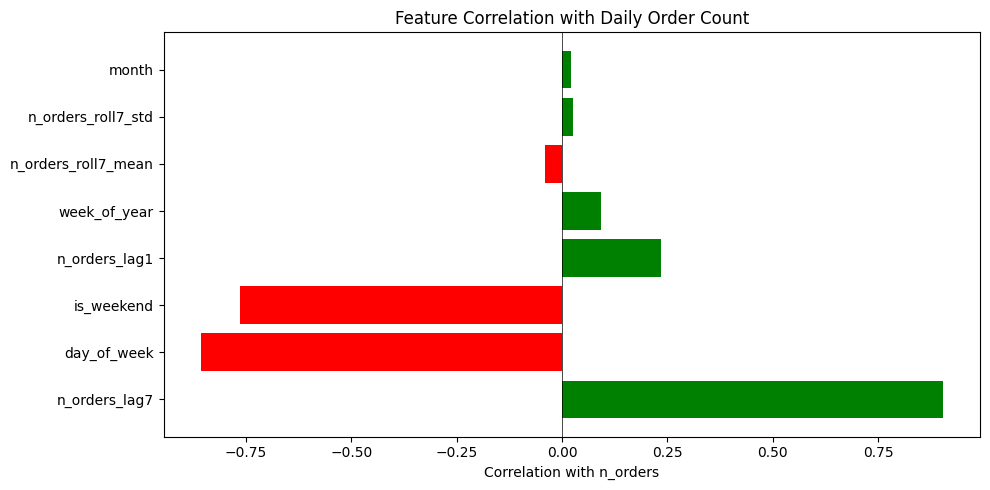


Dataset shape: (106, 10)
Features known before forecast day: 8

Top 5 correlated features:
  n_orders_lag7                  +0.904
  day_of_week                    -0.857
  is_weekend                     -0.763
  n_orders_lag1                  +0.236
  week_of_year                   +0.092


/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1163: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
# 3. FEATURE ADVISOR
# Cechy muszą być znane przed dniem prognozy. Nie używamy miar z dnia t.

import pyspark.sql.functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

# ---- Daily target built directly from orders ----
# This preserves orders whose ordered_products value is empty or malformed.
daily_orders = (
    orders
    .filter(F.col("order_date").isNotNull())
    .groupBy("order_date")
    .agg(F.countDistinct("order_number").alias("n_orders"))
)

# Add missing calendar dates explicitly: no row means zero orders, not missing data.
date_bounds = daily_orders.agg(
    F.min("order_date").alias("min_date"),
    F.max("order_date").alias("max_date"),
).first()
calendar = (
    spark.createDataFrame([(date_bounds["min_date"], date_bounds["max_date"])], ["min_date", "max_date"])
    .select(F.explode(F.sequence("min_date", "max_date")).alias("order_date"))
)

daily_features_sp = calendar.join(daily_orders, "order_date", "left").fillna({"n_orders": 0})

# ---- Calendar features ----
# ISO convention: Monday=1, ..., Sunday=7. Reuse this convention at scoring time.
iso_day_of_week = F.pmod(F.dayofweek("order_date") + F.lit(5), F.lit(7)) + F.lit(1)
daily_features_sp = (
    daily_features_sp
    .withColumn("day_of_week", iso_day_of_week)
    .withColumn("is_weekend", F.when(iso_day_of_week.isin(6, 7), 1).otherwise(0))
    .withColumn("week_of_year", F.weekofyear("order_date"))
    .withColumn("month", F.month("order_date"))
)

# ---- Historical target features ----
# Every rolling window ends at t-1. This prevents the target from leaking into its own features.
w = Window.orderBy("order_date")
w7_history = Window.orderBy("order_date").rowsBetween(-7, -1)
daily_features_sp = (
    daily_features_sp
    .withColumn("n_orders_lag1", F.lag("n_orders", 1).over(w))
    .withColumn("n_orders_lag7", F.lag("n_orders", 7).over(w))
    .withColumn("n_orders_roll7_mean", F.avg("n_orders").over(w7_history))
    .withColumn("n_orders_roll7_std", F.stddev("n_orders").over(w7_history))
)

# ---- Convert to pandas ----
df = daily_features_sp.orderBy("order_date").toPandas()
df["order_date"] = pd.to_datetime(df["order_date"])

# ---- Correlation with target ----
target = "n_orders"
feature_cols = [
    "day_of_week", "is_weekend", "week_of_year", "month",
    "n_orders_lag1", "n_orders_lag7", "n_orders_roll7_mean", "n_orders_roll7_std",
]
corr = df[feature_cols + [target]].corr()[target].drop(target).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if value > 0 else "red" for value in corr]
ax.barh(corr.index, corr.values, color=colors)
ax.set_xlabel(f"Correlation with {target}")
ax.set_title("Feature Correlation with Daily Order Count")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nDataset shape: {df.shape}")
print(f"Features known before forecast day: {len(feature_cols)}")
print("\nTop 5 correlated features:")
for feature, value in corr.head(5).items():
    print(f"  {feature:30s} {value:+.3f}")

## 4. Forecast Runner

Tutaj uruchamiamy porównanie modeli. Najpierw liczone są baseline'y, potem trenowany jest model LightGBM na przygotowanych cechach, a na końcu porównywane są metryki jakości i logowany jest eksperyment w MLflow.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Train: 85 days (2019-08-08 to 2019-10-31)
Test : 14 days (2019-11-01 to 2019-11-14)
Evaluation: one-step-ahead walk-forward; each completed day becomes history for the next forecast.

=== FORECAST RUNNER RESULTS ===


Model,WMAPE,Bias,MAE
LightGBM,0.2111597197758592,0.07479471304876825,7.692246934692014
Seasonal Naive,0.23137254901960785,0.17647058823529413,8.428571428571429
7-day MA,0.3703081232492997,0.16022408963585427,13.489795918367346
Naive,0.403921568627451,0.2901960784313726,14.714285714285714


Best holdout model: LightGBM


2026/09/23 16:54:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://adb-7405615837166522.2.azuredatabricks.net/ml/experiments/4406744677905283/models/m-5cda244388d2461abbe532d0dc688396?o=7405615837166522
2026/09/23 16:54:08 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.



MLflow run_id: 371d913b57174676a8467306b561cc88


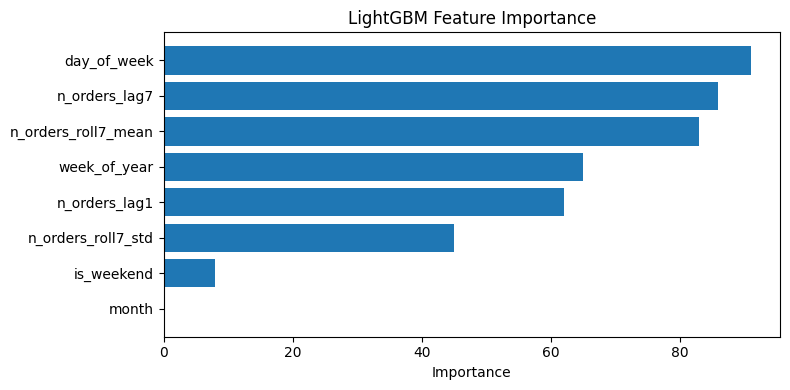

In [0]:
# 4. FORECAST RUNNER

%pip install lightgbm -q
import lightgbm as lgb
import numpy as np
import pandas as pd
import mlflow
import matplotlib.pyplot as plt

# ---- Prepare ----
target = "n_orders"
feature_cols = [
    "day_of_week", "is_weekend", "week_of_year", "month",
    "n_orders_lag1", "n_orders_lag7", "n_orders_roll7_mean", "n_orders_roll7_std",
]
available = [column for column in feature_cols if column in df.columns]
df_model = df.dropna(subset=available + [target]).copy()

# ---- Time split: last 14 days as a one-step-ahead walk-forward holdout ----
cutoff = df_model["order_date"].max() - pd.Timedelta(days=14)
train = df_model[df_model["order_date"] <= cutoff].copy()
test = df_model[df_model["order_date"] > cutoff].copy()
print(f"Train: {len(train)} days ({train['order_date'].min().date()} to {train['order_date'].max().date()})")
print(f"Test : {len(test)} days ({test['order_date'].min().date()} to {test['order_date'].max().date()})")
print("Evaluation: one-step-ahead walk-forward; each completed day becomes history for the next forecast.")

X_train, y_train = train[available], train[target]
X_test, y_test = test[available], test[target]

# ---- Baselines evaluated with the same walk-forward information set ----
def walk_forward_baselines(train_frame, test_frame):
    history = train_frame[["order_date", target, "day_of_week"]].copy()
    naive_predictions, ma7_predictions, seasonal_predictions = [], [], []

    for _, row in test_frame.sort_values("order_date").iterrows():
        naive_predictions.append(float(history[target].iloc[-1]))
        ma7_predictions.append(float(history[target].tail(7).mean()))
        same_day = history.loc[history["day_of_week"] == row["day_of_week"], target]
        seasonal_predictions.append(float(same_day.iloc[-1]) if not same_day.empty else ma7_predictions[-1])
        history.loc[len(history)] = [row["order_date"], row[target], row["day_of_week"]]

    return naive_predictions, ma7_predictions, seasonal_predictions

naive_pred, ma7_pred, snaive_pred = walk_forward_baselines(train, test)

# ---- Metrics ----
def calc_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    wmape = np.sum(np.abs(actual - predicted)) / np.sum(actual) if np.sum(actual) > 0 else np.nan
    bias = np.sum(predicted - actual) / np.sum(actual) if np.sum(actual) > 0 else np.nan
    mae = np.mean(np.abs(actual - predicted))
    return wmape, bias, mae

results = [
    ("Naive", *calc_metrics(y_test, naive_pred)),
    ("7-day MA", *calc_metrics(y_test, ma7_pred)),
    ("Seasonal Naive", *calc_metrics(y_test, snaive_pred)),
]

# ---- LightGBM ----
lgb_model = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=6,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbose=-1,
)
lgb_model.fit(X_train, y_train)
lgb_pred = lgb_model.predict(X_test).clip(min=0)
results.append(("LightGBM", *calc_metrics(y_test, lgb_pred)))

predictions_by_model = {
    "Naive": np.asarray(naive_pred),
    "7-day MA": np.asarray(ma7_pred),
    "Seasonal Naive": np.asarray(snaive_pred),
    "LightGBM": np.asarray(lgb_pred),
}

# ---- Results table ----
results_df = pd.DataFrame(results, columns=["Model", "WMAPE", "Bias", "MAE"])
best_model_name = results_df.sort_values("WMAPE").iloc[0]["Model"]
print("\n=== FORECAST RUNNER RESULTS ===")
display(results_df.sort_values("WMAPE"))
print(f"Best holdout model: {best_model_name}")

# ---- MLflow logging ----
mlflow.set_experiment("/Users/katarzyna.palach@cloudsonmars.com/marketplace_retail_forecast")
with mlflow.start_run(run_name="lgb_daily_orders") as run:
    mlflow.log_params({
        "model_type": "LightGBM",
        "target": target,
        "features": str(available),
        "evaluation": "one-step-ahead walk-forward holdout",
        "train_days": len(train),
        "test_days": len(test),
    })
    for _, row in results_df.iterrows():
        metric_name = row["Model"].replace(" ", "_").replace("-", "")
        mlflow.log_metric(f"wmape_{metric_name}", row["WMAPE"])
        mlflow.log_metric(f"bias_{metric_name}", row["Bias"])
        mlflow.log_metric(f"mae_{metric_name}", row["MAE"])
    mlflow.sklearn.log_model(lgb_model, artifact_path="model")
    run_id = run.info.run_id
    print(f"\nMLflow run_id: {run_id}")

# ---- Feature importance ----
imp = pd.DataFrame({"feature": available, "importance": lgb_model.feature_importances_})
imp = imp.sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp["feature"], imp["importance"])
ax.set_xlabel("Importance")
ax.set_title("LightGBM Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ---- Reusable future feature builder ----
def make_forecast_features(history, forecast_date):
    demand_history = history[target].astype(float)
    if len(demand_history) < 7:
        raise ValueError("At least seven historical days are required for forecasting.")

    return {
        "day_of_week": forecast_date.isoweekday(),
        "is_weekend": int(forecast_date.weekday() >= 5),
        "week_of_year": int(forecast_date.isocalendar().week),
        "month": forecast_date.month,
        "n_orders_lag1": float(demand_history.iloc[-1]),
        "n_orders_lag7": float(demand_history.iloc[-7]),
        "n_orders_roll7_mean": float(demand_history.tail(7).mean()),
        "n_orders_roll7_std": float(demand_history.tail(7).std()),
    }


def forecast_input(history, forecast_date):
    input_df = pd.DataFrame([make_forecast_features(history, forecast_date)], columns=available)
    for column in ["day_of_week", "is_weekend", "week_of_year", "month"]:
        input_df[column] = input_df[column].astype("int32")
    return input_df

## 5. Results Explainer

Ta sekcja pokazuje, jak zachowuje się najlepszy model na zbiorze holdout. Rozbijamy błąd po dniach tygodnia i weekendach, wskazujemy najtrudniejsze dni oraz wizualnie porównujemy wartości rzeczywiste z predykcjami.

=== RESULTS EXPLAINER ===
Champion on holdout: LightGBM

--- Error by Day of Week ---
  Monday        WMAPE=0.0952  Bias=+0.0952  n=2
  Tuesday       WMAPE=0.1990  Bias=+0.1990  n=2
  Wednesday     WMAPE=0.2262  Bias=+0.0035  n=2
  Thursday      WMAPE=0.2025  Bias=-0.0389  n=2
  Friday        WMAPE=0.2489  Bias=+0.2489  n=2
  Saturday      WMAPE=0.4968  Bias=+0.2267  n=2
  Sunday        WMAPE=0.2848  Bias=-0.2848  n=2

--- Error: Weekday vs Weekend ---
  Weekday     WMAPE=0.1874  Bias=+0.1000  n=10
  Weekend     WMAPE=0.3658  Bias=-0.0892  n=4

--- Largest Errors ---
  2019-11-12 (Tuesday  )  actual=53  pred=64.5  error=11.5
  2019-11-07 (Thursday )  actual=52  pred=41.5  error=10.5
  2019-11-08 (Friday   )  actual=27  pred=37.1  error=10.1


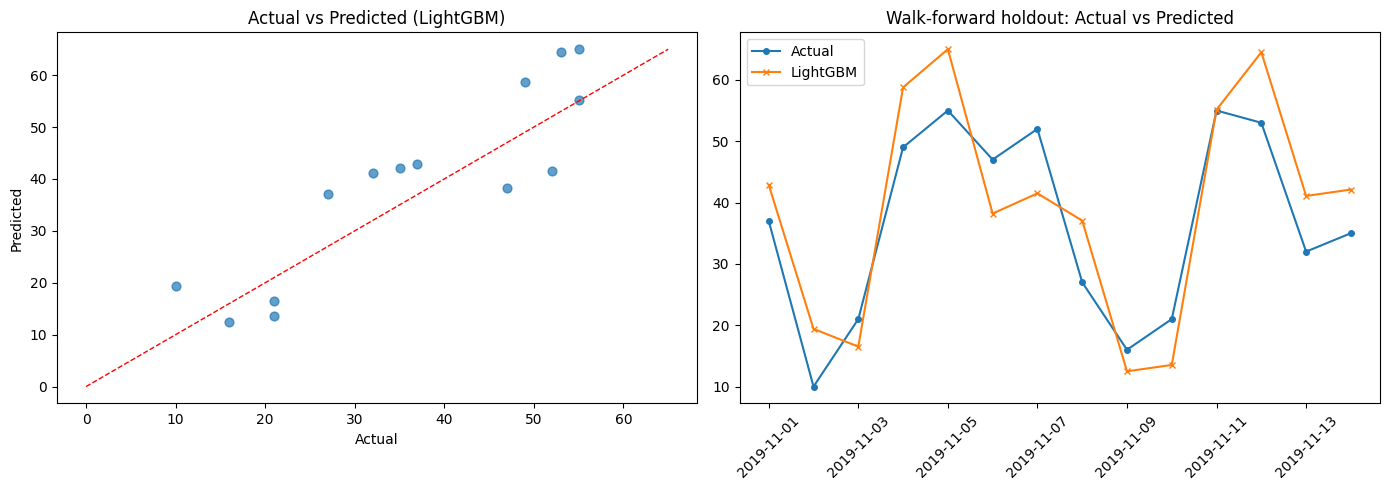

In [0]:
# 5. RESULTS EXPLAINER

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Explain the actual holdout winner, not LightGBM by assumption.
champion_predictions = predictions_by_model[best_model_name]
test_res = test.copy()
test_res["predicted"] = champion_predictions
test_res["error"] = np.abs(test_res[target] - test_res["predicted"])
test_res["day_name"] = test_res["order_date"].dt.day_name()
test_res["wknd"] = test_res["is_weekend"].map({0: "Weekday", 1: "Weekend"})

# ---- Breakdown by day of week ----
def wmape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(actual) if np.sum(actual) > 0 else np.nan


def bias_fn(actual, predicted):
    return np.sum(predicted - actual) / np.sum(actual) if np.sum(actual) > 0 else np.nan

print("=== RESULTS EXPLAINER ===")
print(f"Champion on holdout: {best_model_name}")
print("\n--- Error by Day of Week ---")
for day_name in ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]:
    subset = test_res[test_res["day_name"] == day_name]
    if not subset.empty:
        day_wmape = wmape(subset[target].values, subset["predicted"].values)
        day_bias = bias_fn(subset[target].values, subset["predicted"].values)
        print(f"  {day_name:12s}  WMAPE={day_wmape:.4f}  Bias={day_bias:+.4f}  n={len(subset)}")

print("\n--- Error: Weekday vs Weekend ---")
for group in ["Weekday", "Weekend"]:
    subset = test_res[test_res["wknd"] == group]
    if not subset.empty:
        group_wmape = wmape(subset[target].values, subset["predicted"].values)
        group_bias = bias_fn(subset[target].values, subset["predicted"].values)
        print(f"  {group:10s}  WMAPE={group_wmape:.4f}  Bias={group_bias:+.4f}  n={len(subset)}")

# ---- Worst days ----
print("\n--- Largest Errors ---")
worst = test_res.nlargest(3, "error")[["order_date", "day_name", target, "predicted", "error"]]
for _, row in worst.iterrows():
    print(
        f"  {row['order_date'].date()} ({row['day_name']:9s})  "
        f"actual={row[target]:.0f}  pred={row['predicted']:.1f}  error={row['error']:.1f}"
    )

# ---- Charts ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(test_res[target], test_res["predicted"], alpha=0.7, s=40)
max_value = max(test_res[target].max(), test_res["predicted"].max())
axes[0].plot([0, max_value], [0, max_value], "r--", linewidth=1)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Actual vs Predicted ({best_model_name})")

axes[1].plot(test_res["order_date"], test_res[target], label="Actual", marker="o", markersize=4)
axes[1].plot(test_res["order_date"], test_res["predicted"], label=best_model_name, marker="x", markersize=4)
axes[1].set_title("Walk-forward holdout: Actual vs Predicted")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Business Recommender

Na końcu przekładamy wynik modelowania na decyzje biznesowe. Sekcja wybiera zwycięzcę na holdoucie, formułuje rekomendacje operacyjne oraz, gdy wygrywa LightGBM, rejestruje model kandydujący po ponownym treningu na pełnej historii. Ustawienie aliasu `Champion` pozostaje osobną, świadomą decyzją w Unity Catalog.

In [0]:
# 6. BUSINESS RECOMMENDER

import pandas as pd
import mlflow
import lightgbm as lgb
from mlflow.models import infer_signature

MODEL_NAME = "sandbox.default.marketplace_retail_daily_orders"

print("=" * 70)
print("BUSINESS RECOMMENDER")
print("=" * 70)

# ---- Headline ----
lgb_row = results_df[results_df["Model"] == "LightGBM"].iloc[0]
baseline_best = results_df[results_df["Model"] != "LightGBM"].sort_values("WMAPE").iloc[0]
best_model_name = results_df.sort_values("WMAPE").iloc[0]["Model"]
improvement_pp = (baseline_best["WMAPE"] - lgb_row["WMAPE"]) * 100

print("\n--- HEADLINE ---")
if lgb_row["WMAPE"] < baseline_best["WMAPE"]:
    print(f"LightGBM beats the best baseline ({baseline_best['Model']}) by {improvement_pp:.1f} WMAPE pp.")
else:
    print(f"LightGBM does NOT beat the best baseline ({baseline_best['Model']}).")
print(f"LightGBM WMAPE: {lgb_row['WMAPE']:.3f}; MAE: {lgb_row['MAE']:.1f}")
print(f"Best baseline : {baseline_best['WMAPE']:.3f} ({baseline_best['Model']})")
print(f"Champion on holdout: {best_model_name}")

# ---- Recommendations ----
print("""
--- 3 RECOMMENDATIONS ---
1. Staffing & logistics: Use next-day order predictions to adjust warehouse
   staffing and delivery capacity 24h ahead.

2. Inventory replenishment: Use the weekly rhythm in the forecast as an input
   to reorder-point logic for fast-moving SKUs.

3. Marketing spend timing: Schedule campaigns on predicted low-order days to
   smooth demand, reducing peaks that strain fulfillment.

--- LIMITATIONS ---
- Only 106 days of history. No full seasonal cycle (Aug-Nov 2019 only).
- Single Marketplace sample dataset, not production data.
- Daily grain hides intra-day patterns. Hourly would improve staffing.
- No external signals (planned promotions, holidays, weather) are included.
- P10-P90 forecast intervals (section 7) come from separately trained quantile
  models; check their actual holdout coverage there before relying on them for
  staffing decisions -- it can fall well short of the 80% target.
""")

# ---- Register an evaluated candidate; promotion to Champion is a separate governed decision ----
print("--- MODEL REGISTRY ---")
candidate_model_uri = None

if best_model_name == "LightGBM":
    # Refit only after model selection, now using all observed history.
    final_lgb_model = lgb.LGBMRegressor(**lgb_model.get_params())
    X_full, y_full = df_model[available], df_model[target]
    final_lgb_model.fit(X_full, y_full)

    input_example = X_full.head(5).copy()
    signature = infer_signature(input_example, final_lgb_model.predict(input_example))
    with mlflow.start_run(run_name="lgb_daily_orders_candidate") as registry_run:
        mlflow.sklearn.log_model(
            final_lgb_model,
            name="model",
            signature=signature,
            input_example=input_example,
        )
        candidate_run_id = registry_run.info.run_id

    candidate_model_uri = f"runs:/{candidate_run_id}/model"
    registered = mlflow.register_model(candidate_model_uri, MODEL_NAME)
    print(f"Registered candidate: {registered.name}, version: {registered.version}")
    print("The Champion alias was not changed. Promote this version only after review.")
else:
    print(f"Champion is '{best_model_name}', a rule-based baseline. No MLflow model was registered.")

# ---- Candidate scoring demo ----
print("\n--- NEXT-DAY SCORING DEMO ---")
latest_history = df_model[["order_date", target]].copy()
next_date = latest_history["order_date"].iloc[-1] + pd.Timedelta(days=1)

if best_model_name == "LightGBM":
    next_day_features = forecast_input(latest_history, next_date)
    prediction = float(final_lgb_model.predict(next_day_features)[0])
else:
    # The same baseline definitions used in the walk-forward evaluation.
    if best_model_name == "Naive":
        prediction = float(latest_history[target].iloc[-1])
    elif best_model_name == "7-day MA":
        prediction = float(latest_history[target].tail(7).mean())
    elif best_model_name == "Seasonal Naive":
        next_day_of_week = next_date.isoweekday()
        history_with_calendar = df_model[df_model["day_of_week"] == next_day_of_week]
        prediction = float(history_with_calendar[target].iloc[-1])
    else:
        raise ValueError(f"Unsupported champion model: {best_model_name}")

print(f"Model used for scoring: {best_model_name}")
print(f"Prediction for {next_date.date()}: {max(prediction, 0):.0f} orders")

print("\n" + "=" * 70)
print("END OF SKILLS PIPELINE")
print("=" * 70)

BUSINESS RECOMMENDER

--- HEADLINE ---
LightGBM beats the best baseline (Seasonal Naive) by 2.0 WMAPE pp.
LightGBM WMAPE: 0.211; MAE: 7.7
Best baseline : 0.231 (Seasonal Naive)
Champion on holdout: LightGBM

--- 3 RECOMMENDATIONS ---
1. Staffing & logistics: Use next-day order predictions to adjust warehouse
   staffing and delivery capacity 24h ahead.

2. Inventory replenishment: Use the weekly rhythm in the forecast as an input
   to reorder-point logic for fast-moving SKUs.

3. Marketing spend timing: Schedule campaigns on predicted low-order days to
   smooth demand, reducing peaks that strain fulfillment.

--- LIMITATIONS ---
- Only 106 days of history. No full seasonal cycle (Aug-Nov 2019 only).
- Single Marketplace sample dataset, not production data.
- Daily grain hides intra-day patterns. Hourly would improve staffing.
- No external signals (planned promotions, holidays, weather) are included.
- P10-P90 forecast intervals (section 7) come from separately trained quantile
  mod

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
🔗 View Logged Model at: https://adb-7405615837166522.2.azuredatabricks.net/ml/experiments/4406744677905283/models/m-7457f58ff6854f4a8ba719d6488e8889?o=7405615837166522
Registered model 'sandbox.default.marketplace_retail_daily_orders' alrea

Uploading artifacts:   0%|          | 0/12 [00:00<?, ?it/s]

🔗 Created version '9' of model 'sandbox.default.marketplace_retail_daily_orders': https://adb-7405615837166522.2.azuredatabricks.net/explore/data/models/sandbox/default/marketplace_retail_daily_orders/version/9?o=7405615837166522


Registered candidate: sandbox.default.marketplace_retail_daily_orders, version: 9
The Champion alias was not changed. Promote this version only after review.

--- NEXT-DAY SCORING DEMO ---
Model used for scoring: LightGBM
Prediction for 2019-11-15: 33 orders

END OF SKILLS PIPELINE


## 7. Model Query

Ta sekcja odczytuje **najnowszą zarejestrowaną wersję** modelu z registry (`sandbox.default.marketplace_retail_daily_orders`) — nie sprawdza ani nie wymaga aliasu `Champion` w Unity Catalog, więc każdy nowy przebieg sekcji 6 automatycznie staje się tym, co prognozuje sekcja 7. Jeśli przed użyciem prognoz produkcyjnie potrzebna jest formalna, ręczna akceptacja modelu, dodaj tu krok wczytujący konkretną, zatwierdzoną wersję (np. przez alias) zamiast najnowszej. Sekcja buduje cechy dla kolejnych N dni wyłącznie z kalendarza, obserwowanej historii i wcześniejszych predykcji. Przedziały P10–P90 pochodzą z osobnych modeli kwantylowych LightGBM; przed użyciem pokazujemy ich rzeczywiste pokrycie na holdoucie. Można zmieniać horyzont (`FORECAST_DAYS`) i porównać pokrycie z celem 80%.

Loaded model: sandbox.default.marketplace_retail_daily_orders, version 9 (latest registered, not a reviewed alias)
Evaluating P10-P90 interval coverage on the walk-forward holdout...
Observed P10-P90 coverage on holdout: 57.1% (target: about 80%)
Coverage is well below target: treat the interval as an optimistic lower bound on uncertainty, not a calibrated 80% band.
Last observed day: 2019-11-14
Forecast horizon: 7 days

=== LATEST MODEL FORECAST (P10-P90 interval) ===
Date           Day            P10  Pred   P90
----------------------------------------------------
2019-11-15     Friday          26    33    35
2019-11-16     Saturday        13    18    31
2019-11-17     Sunday          11    17    26
2019-11-18     Monday          37    50    50
2019-11-19     Tuesday         42    55    57
2019-11-20     Wednesday       39    41    47
2019-11-21     Thursday        34    41    47

Average daily orders: 36
Total for 7 days: 255 orders
Mean interval width: 13 orders/day


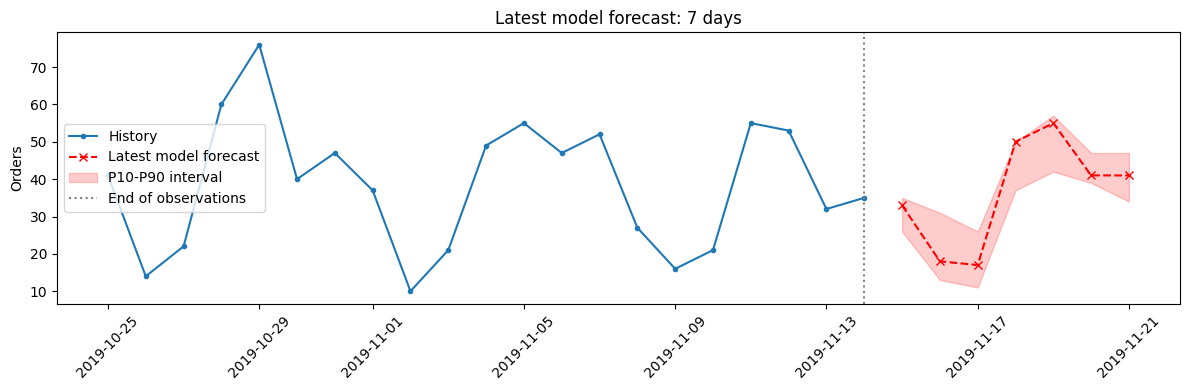

In [0]:
# 7. MODEL QUERY -- latest registered model + calibrated interval diagnostics

import mlflow
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from mlflow import MlflowClient

# ---- Configuration ----
FORECAST_DAYS = 7
MODEL_NAME = "sandbox.default.marketplace_retail_daily_orders"

# ---- Load the latest registered version ----
# This does not check a "Champion" alias -- every new candidate from section 6
# becomes what this section forecasts with. For a production gate, replace this
# with a specific approved version (e.g. loaded via an alias set manually in
# Unity Catalog after review).
client = MlflowClient()
all_versions = client.search_model_versions(f"name='{MODEL_NAME}'")
if not all_versions:
    raise RuntimeError(f"No versions found for {MODEL_NAME}. Run cell 6 (Business Recommender) first.")
latest_mv = max(all_versions, key=lambda v: int(v.version))
champion = mlflow.pyfunc.load_model(f"models:/{MODEL_NAME}/{latest_mv.version}")
print(f"Loaded model: {MODEL_NAME}, version {latest_mv.version} (latest registered, not a reviewed alias)")

# ---- Quantile intervals: assess coverage on the held-out period before refitting ----
print("Evaluating P10-P90 interval coverage on the walk-forward holdout...")
quantile_params = {
    "objective": "quantile",
    "n_estimators": 200,
    "learning_rate": 0.05,
    "max_depth": 6,
    "verbose": -1,
    "random_state": 42,
}
q10_evaluation = lgb.LGBMRegressor(alpha=0.10, **quantile_params).fit(X_train, y_train)
q90_evaluation = lgb.LGBMRegressor(alpha=0.90, **quantile_params).fit(X_train, y_train)
q10_holdout = q10_evaluation.predict(X_test)
q90_holdout = q90_evaluation.predict(X_test)
lower_holdout = np.minimum(q10_holdout, q90_holdout)
upper_holdout = np.maximum(q10_holdout, q90_holdout)
interval_coverage = np.mean((y_test.to_numpy() >= lower_holdout) & (y_test.to_numpy() <= upper_holdout))
print(f"Observed P10-P90 coverage on holdout: {interval_coverage:.1%} (target: about 80%)")
if interval_coverage < 0.7:
    print("Coverage is well below target: treat the interval as an optimistic lower bound on uncertainty, not a calibrated 80% band.")

# Refit interval models on all history only after reporting the holdout diagnostic.
X_full, y_full = df_model[available], df_model[target]
lgb_q10 = lgb.LGBMRegressor(alpha=0.10, **quantile_params).fit(X_full, y_full)
lgb_q90 = lgb.LGBMRegressor(alpha=0.90, **quantile_params).fit(X_full, y_full)

# ---- Recursive forecasts using only known calendar values and previous observations/predictions ----
last_date = df_model["order_date"].iloc[-1]
print(f"Last observed day: {last_date.date()}")
print(f"Forecast horizon: {FORECAST_DAYS} days\n")

forecast_rows = []
forecast_history = df_model[["order_date", target]].copy()
forecast_history[target] = forecast_history[target].astype(float)

for step in range(1, FORECAST_DAYS + 1):
    forecast_date = last_date + pd.Timedelta(days=step)
    input_df = forecast_input(forecast_history, forecast_date)

    point_prediction = max(float(champion.predict(input_df)[0]), 0)
    lower_prediction = max(float(lgb_q10.predict(input_df)[0]), 0)
    upper_prediction = max(float(lgb_q90.predict(input_df)[0]), 0)
    lower_prediction, upper_prediction = sorted((lower_prediction, upper_prediction))
    # The point forecast comes from a separately trained model than the quantile
    # pair, so it isn't guaranteed to fall inside [P10, P90]; clip it so the
    # reported interval is always internally consistent.
    point_prediction = min(max(point_prediction, lower_prediction), upper_prediction)

    forecast_rows.append({
        "order_date": forecast_date,
        "predicted_orders": point_prediction,
        "lower": lower_prediction,
        "upper": upper_prediction,
    })
    # Future targets are unknown, so subsequent lag features use the prediction.
    forecast_history.loc[len(forecast_history)] = [forecast_date, point_prediction]

# ---- Results ----
forecast_df = pd.DataFrame(forecast_rows)
forecast_df["order_date"] = pd.to_datetime(forecast_df["order_date"])
forecast_df["day_name"] = forecast_df["order_date"].dt.day_name()
for column in ["predicted_orders", "lower", "upper"]:
    forecast_df[column] = forecast_df[column].round(0).astype(int)

print("=== LATEST MODEL FORECAST (P10-P90 interval) ===")
print(f"{'Date':<14} {'Day':<12} {'P10':>5} {'Pred':>5} {'P90':>5}")
print("-" * 52)
for _, row in forecast_df.iterrows():
    print(
        f"{row['order_date'].date()!s:<14} {row['day_name']:<12} "
        f"{row['lower']:>5} {row['predicted_orders']:>5} {row['upper']:>5}"
    )

print(f"\nAverage daily orders: {forecast_df['predicted_orders'].mean():.0f}")
print(f"Total for {FORECAST_DAYS} days: {forecast_df['predicted_orders'].sum()} orders")
print(f"Mean interval width: {(forecast_df['upper'] - forecast_df['lower']).mean():.0f} orders/day")

# ---- History + forecast chart ----
fig, ax = plt.subplots(figsize=(12, 4))
history_tail = df_model.tail(21)
ax.plot(history_tail["order_date"], history_tail[target], label="History", marker="o", markersize=3)
ax.plot(
    forecast_df["order_date"],
    forecast_df["predicted_orders"],
    label="Latest model forecast",
    marker="x",
    markersize=6,
    color="red",
    linestyle="--",
)
ax.fill_between(
    forecast_df["order_date"],
    forecast_df["lower"],
    forecast_df["upper"],
    alpha=0.2,
    color="red",
    label="P10-P90 interval",
)
ax.axvline(last_date, color="gray", linestyle=":", label="End of observations")
ax.set_title(f"Latest model forecast: {FORECAST_DAYS} days")
ax.set_ylabel("Orders")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 8. Komentarz biznesowy + klasyfikacja

Ostatnia sekcja generuje raport biznesowy i rekomendacje staffingowe **wyłącznie na podstawie predykcji champion modelu** — bez wywołań LLM. Progi klasyfikacji (P25/mediana/P75) pochodzą z rozkładu danych treningowych, a komentarz budowany jest szablonem na wynikach z sekcji 7.

In [0]:

# 8. Komentarz biznesowy + klasyfikacja staffingu
#    Całość oparta na predykcjach champion modelu — bez LLM

import pandas as pd
import numpy as np

# ---- Progi z rozkładu danych treningowych ----
train_median = float(df_model[target].median())
train_p75 = float(df_model[target].quantile(0.75))
train_p25 = float(df_model[target].quantile(0.25))
train_mean = float(df_model[target].mean())

# ---- Klasyfikacja staffingu ----
def classify_staffing(row):
    pred = row["predicted_orders"]
    is_wknd = row["day_name"] in ("Saturday", "Sunday")
    if pred >= train_p75 or (is_wknd and pred >= train_median):
        return "extra_staffing_needed"
    elif pred <= train_p25 and not is_wknd:
        return "reduced_staffing_ok"
    else:
        return "normal_staffing"

staffing_df = forecast_df[["order_date", "day_name", "predicted_orders", "lower", "upper"]].copy()
staffing_df["staffing_recommendation"] = staffing_df.apply(classify_staffing, axis=1)

# ---- Komentarz biznesowy ----
total = int(staffing_df["predicted_orders"].sum())
avg_daily = staffing_df["predicted_orders"].mean()
peak = staffing_df.loc[staffing_df["predicted_orders"].idxmax()]
low = staffing_df.loc[staffing_df["predicted_orders"].idxmin()]
ci_spread = (staffing_df["upper"] - staffing_df["lower"]).mean()
extra_days = staffing_df[staffing_df["staffing_recommendation"] == "extra_staffing_needed"]["day_name"].tolist()
reduced_days = staffing_df[staffing_df["staffing_recommendation"] == "reduced_staffing_ok"]["day_name"].tolist()

trend = "stabilna" if abs(avg_daily - train_mean) / train_mean < 0.1 else (
    "wzrostowa" if avg_daily > train_mean else "spadkowa"
)
ci_pct = ci_spread / avg_daily * 100 if avg_daily > 0 else 0
ci_desc = "wąski (pewna prognoza)" if ci_pct < 15 else (
    "umiarkowany" if ci_pct < 30 else "szeroki (większa niepewność)"
)

print("=" * 70)
print("KOMENTARZ BIZNESOWY (champion model + reguły, bez LLM)")
print("=" * 70)
print(f"""
PROGNOZA: {staffing_df['order_date'].min().strftime('%d.%m')} – {staffing_df['order_date'].max().strftime('%d.%m.%Y')}

1. TREND: {total} zamówień na {len(staffing_df)} dni (śr. {avg_daily:.0f}/dzień).
   Tendencja: {trend} (historyczna średnia: {train_mean:.0f}/dzień).

2. PERSONEL:
   Szczyt: {peak['day_name']} ({int(peak['predicted_orders'])} zam.)
   Minimum: {low['day_name']} ({int(low['predicted_orders'])} zam.)
   Extra staffing: {', '.join(extra_days) if extra_days else 'brak'}.
   Redukcja: {', '.join(reduced_days) if reduced_days else 'brak'}.

3. PEWNOŚĆ: CI ±{ci_spread/2:.0f} zam./dzień ({ci_desc}).
   Progi klasyfikacji: P25={train_p25:.0f}, mediana={train_median:.0f}, P75={train_p75:.0f}.
""")

print("--- TABELA PROGNOZ Z KLASYFIKACJĄ ---")
display(spark.createDataFrame(staffing_df))

KOMENTARZ BIZNESOWY (champion model + reguły, bez LLM)

PROGNOZA: 15.11 – 21.11.2019

1. TREND: 255 zamówień na 7 dni (śr. 36/dzień).
   Tendencja: stabilna (historyczna średnia: 37/dzień).

2. PERSONEL:
   Szczyt: Tuesday (55 zam.)
   Minimum: Sunday (17 zam.)
   Extra staffing: Tuesday.
   Redukcja: brak.

3. PEWNOŚĆ: CI ±6 zam./dzień (szeroki (większa niepewność)).
   Progi klasyfikacji: P25=22, mediana=35, P75=52.

--- TABELA PROGNOZ Z KLASYFIKACJĄ ---


order_date,day_name,predicted_orders,lower,upper,staffing_recommendation
2019-11-15T00:00:00.000Z,Friday,33,26,35,normal_staffing
2019-11-16T00:00:00.000Z,Saturday,18,13,31,normal_staffing
2019-11-17T00:00:00.000Z,Sunday,17,11,26,normal_staffing
2019-11-18T00:00:00.000Z,Monday,50,37,50,normal_staffing
2019-11-19T00:00:00.000Z,Tuesday,55,42,57,extra_staffing_needed
2019-11-20T00:00:00.000Z,Wednesday,41,39,47,normal_staffing
2019-11-21T00:00:00.000Z,Thursday,41,34,47,normal_staffing


## 9. Pytanie do Genie

Genie odpytuje tabele w Unity Catalog, nie zmienne w pamięci notebooka. Ta sekcja zapisuje dwie wąskie, już zagregowane tabele, żeby dało się zadawać pytania w naturalnym języku o historię zamówień i o prognozę:

- `marketplace_retail_daily_actuals` — dzienna liczba zamówień (rzeczywista), z dniem tygodnia i flagą weekendu.
- `marketplace_retail_forecast_output` — prognoza na kolejne `FORECAST_DAYS` dni z przedziałem P10–P90 i rekomendacją staffingu (dokładnie to, co widać w tabeli z sekcji 8).

Obie tabele są nadpisywane (`overwrite`) przy każdym uruchomieniu notebooka, więc zawsze odzwierciedlają najnowszy przebieg.

In [0]:
# 9.  curated tables for natural-language Q&A

GENIE_SCHEMA = "sandbox.default"

# ---- Daily actuals: exact grain the business questions need, no JSON/epoch columns ----
daily_actuals_pd = df_model[["order_date", target, "day_of_week", "is_weekend"]].rename(
    columns={target: "n_orders"}
).copy()
daily_actuals_pd["day_name"] = daily_actuals_pd["order_date"].dt.day_name()

(
    spark.createDataFrame(daily_actuals_pd)
    .write.mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{GENIE_SCHEMA}.marketplace_retail_daily_actuals")
)
print(f"Wrote {len(daily_actuals_pd):,} rows to {GENIE_SCHEMA}.marketplace_retail_daily_actuals")

# ---- Forecast output: exactly what section 8 already computed, persisted as-is ----
(
    spark.createDataFrame(staffing_df)
    .write.mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(f"{GENIE_SCHEMA}.marketplace_retail_forecast_output")
)
print(f"Wrote {len(staffing_df):,} rows to {GENIE_SCHEMA}.marketplace_retail_forecast_output")

Wrote 99 rows to sandbox.default.marketplace_retail_daily_actuals
Wrote 7 rows to sandbox.default.marketplace_retail_forecast_output
